# 32_alarm_explain_JIW

- 목적: 경보가 났을 때 **무엇 때문에 났는지**를 코드로 뽑은 근거(어느 모델이 얼마나 넘었나, 어느 신호에서 벗어났나)와 템플릿 문장·점검 권고로 보여 주는 **근거 카드**를 만들고, 근거가 맞는지 합성 이상으로 검증한다. 설계: `docs/final_design_JIW.md` §5.
- 입력: 24·26의 저장 가중치(CNN, MCD[amp]), 28번의 경보 규칙(주의 = CNN 초과, 경보 = CNN AND MCD 초과). **새로 학습하지 않는다.**
- 출력: `figures/32_alarm_explain_JIW/`, `results/32_alarm_explain_JIW/`(attribution.csv · cards.csv)
- 담당: JIW
- 탐지 대상: 유압펌프 모터-펌프 구동부 이상. 센서 부착 부위를 확정할 수 없어 카드는 **신호 이름**(상부 진동·하부 진동·전류)만 말하고 모터/펌프를 단정하지 않는다.
- 심사 대응: 3번(경보 조건별 FP·FN 근거), 4번(경보 → 조치 연결), 5번(도메인 신호 기반 설명)
- 근거 표기: **[데이터]** 이 노트북 출력 / **[추정]** 미검증 / **[가정]** 도메인·운영 전제

## 한계를 먼저

실제 이상 1건에는 원인 라벨이 없어서 **"설명이 실제 원인과 맞는가"는 측정할 수 없다.** 그래서 두 가지만 한다.
1. 합성 이상에서 근거가 **주입한 채널**을 가리키는지 센다(§2). 방법의 정합성 검증이지 실제 고장 진단 성능이 아니다.
2. 실제 이상 창에서 카드가 어떻게 나오는지 **기술**한다(§3).

점검 권고는 가이드북·일반 설비 상식에서 온 **가정**이다. LLM 문장화는 구현하지 않았다(외부 API 허용 여부 미확인, 템플릿이 기본).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "32_alarm_explain_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B
import explain_jiw as X
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 600)
MODEL_SEED = 0     # 사용할 저장 가중치의 시드
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

32_alarm_explain_JIW figures\32_alarm_explain_JIW results\32_alarm_explain_JIW


## 1. 근거 카드가 담는 것

| 항목 | 계산 | 의미 |
|---|---|---|
| 단계 | 경보 = CNN AND MCD 초과, 주의 = CNN 단독 초과 | 28번 결과의 포함 관계 |
| 모델별 배수 | 점수 / 임계(train 정상 q99) | 임계를 몇 배 넘었나 |
| 예측 오차 비중 | CNN 시점 오차 `(e/sd)²`를 창 안에서 채널별로 합해 1로 맞춤 | 어느 센서에서 예측이 크게 빗나갔나 |
| 통계 이탈 상위 3 | MCD 입력 18피처를 train 정상 평균·표준편차로 표준화한 값의 절댓값 상위 3 | 정상 대비 어떤 통계가 커졌나 |
| 운전 상태 추정 | 창 전류 RMS > 125.2면 고부하 | 고부하 오경보 맥락 |
| 점검 권고 | 오차 비중 1위 채널 → 점검 항목 표 [가정] | 조치 연결 |

MCD의 이탈 피처는 마할라노비스 거리의 정확한 분해가 아니라 **표준화 편차**(단변량)다. 피처 사이 상관을 반영하지 않으므로 "가장 눈에 띄는 변화"로만 읽는다.

## 2. 합성 이상으로 근거 정합성 검증

정상 test 창에 4유형 × 강도 4단계를 넣고, CNN 경보가 난 창(`z_cnn > 1`)에서 카드의 1순위 근거가 **주입한 채널**과 같은지 센다. `benchmark_jiw.inject`가 건드리는 채널: 스파이크 = 상부 진동, 진폭 증가 = 상·하부 진동, 상하 반대 흔들림 = 하부 진동, 전류 불규칙 = 전류.

In [2]:
segs, W = B.load_inputs()
attr = X.synthetic_attribution(segs, W, seed=MODEL_SEED, progress=False)
tab = attr.groupby(["kind", "sev"]).agg(n_cards=("cnn_hit", "size"), cnn_hit=("cnn_hit", "mean"), mcd_hit=("mcd_hit", "mean")).round(3)
tab.to_csv(RES / "attribution.csv")
tab

n_cards  cnn_hit  mcd_hit
kind      sev                           
amplitude 1.0      239    0.979    0.971
          2.0     1245    0.944    0.956
          4.0     2223    0.960    0.982
          8.0     2254    0.971    1.000
antiphase 1.0       96    0.719    0.302
          2.0     1192    0.984    0.604
          4.0     2198    1.000    0.848
          8.0     2254    1.000    0.989
current   1.0     1312    0.991    0.710
          2.0     2252    1.000    0.913
          4.0     2254    1.000    0.983
          8.0     2254    1.000    0.999
spike     1.0     1444    0.996    0.882
          2.0     2021    0.999    0.979
          4.0     2059    0.999    0.978
          8.0     2069    0.999    0.984

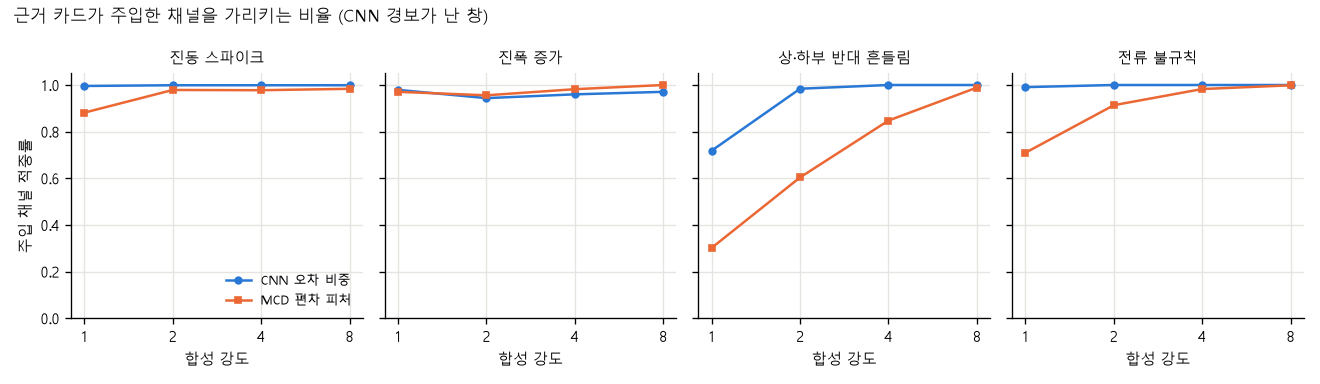

In [3]:
X.plot_attribution(attr, FIG); display(Image(FIG / "attribution.png"))

**발견 [데이터]**
- **CNN 오차 비중**은 4유형 모두 강도 2 이상에서 94~100%로 주입한 채널을 가리킨다. 강도 1에서도 진폭 98%·전류 99%·스파이크 100%다. 약한 경우는 **상하 반대 흔들림 강도 1**(72%)뿐이다. 이 유형은 하부 진동에 상부 진동의 일부를 섞은 것이라 상부 진동도 같이 흔들려 오차가 갈린다.
- **MCD 편차 피처**는 강한 이상(강도 4 이상)에서는 맞지만 약한 이상에서 떨어진다(상하 반대 흔들림 강도 1·2에서 30%·60%). 단변량 표준화 편차는 채널 사이 관계 변화를 잘 가리키지 못한다.
- 따라서 카드의 **1순위 채널은 CNN 오차 비중**을 쓰고, MCD 피처는 보조 정보로 둔다.

**한계.** 주입 신호는 우리가 만든 4유형이라 "맞는 원인"이 정의돼 있다. 실제 설비 고장의 원인 분류에 이 적중률이 그대로 적용된다는 뜻이 아니다.

## 3. 실제 이상 창과 오경보 창의 카드

`group_kfold_seg` 5개 fold의 test에서 경보(CNN AND MCD)가 난 창만 카드를 만든다. 실제 이상 21 세그먼트 중 2초 창이 있는 세그먼트가 대상이다.

In [4]:
cards = X.real_cards(segs, W, seed=MODEL_SEED, progress=False)
cards.to_csv(RES / "cards.csv", index=False)
print("카드 수", len(cards), " 실제 이상 창", int((cards.label == 1).sum()), " 정상(오경보) 창", int((cards.label == 0).sum()))
real_c = cards[cards.label == 1]
by_seg = real_c.groupby("seg_uid").agg(창수=("seg_uid", "size"), 상부진동=("share_ai0", "mean"), 하부진동=("share_ai1", "mean"), 전류=("share_ai2", "mean"),
                                      vib_grade=("vib_grade", "first"), cur_grade=("cur_grade", "first")).round(2)
by_seg

카드 수 64  실제 이상 창 63  정상(오경보) 창 1


,창수,상부진동,하부진동,전류,vib_grade,cur_grade
seg_uid,,,,,,
outlier_1,7,0.40,0.36,0.24,확실 이상,경계
outlier_11,7,0.24,0.25,0.52,확실 이상,경계
outlier_12,5,0.43,0.26,0.30,확실 이상,정상 유사
outlier_13,2,0.71,0.10,0.19,확실 이상,경계
outlier_15,7,0.28,0.19,0.53,확실 이상,확실 이상
outlier_16,7,0.10,0.16,0.74,확실 이상,확실 이상
outlier_17,4,0.47,0.22,0.32,확실 이상,확실 이상
outlier_18,1,0.74,0.08,0.18,확실 이상,확실 이상
outlier_2,6,0.58,0.17,0.25,확실 이상,경계


In [5]:
# 창 단위 1순위 채널 분포 (실제 이상 창)
real_c["top_channel"].map(X.CH_KO).value_counts().rename("창 수").to_frame().assign(비율=lambda d: (d["창 수"] / d["창 수"].sum()).round(2))

,창 수,비율
top_channel,,
전류,30,0.48
상부 진동,27,0.43
하부 진동,6,0.10


In [6]:
# 카드 예시: 전류 비중이 가장 큰 세그먼트, 상부 진동 비중이 가장 큰 세그먼트, 정상인데 경보가 난 창
ex = [by_seg["전류"].idxmax(), by_seg["상부진동"].idxmax()]
for u in ex:
    print(real_c[real_c.seg_uid == u].iloc[0]["text"]); print()
fp = cards[cards.label == 0]
print("[AND 오경보 정상 창]", fp.iloc[0]["text"] if len(fp) else "없음")

[경보] 전류 쪽 이상 의심. CNN 점수가 임계의 11.2배, MCD 점수가 임계의 9.3배. 예측 오차 비중: 상부 진동 3% · 하부 진동 2% · 전류 94%. 정상에서 가장 벗어난 통계: 전류 첨도 +29.8σ, 하부 진동 첨도 +10.7σ, 전류 크레스트 팩터 +10.5σ. 운전 상태 추정: 저부하. 점검 권고(가정): 전원·부하 변동, 토출 압력.

[경보] 상부 진동 쪽 이상 의심. CNN 점수가 임계의 51.2배, MCD 점수가 임계의 9.5배. 예측 오차 비중: 상부 진동 74% · 하부 진동 8% · 전류 18%. 정상에서 가장 벗어난 통계: 상부 진동 피크-피크 +35.3σ, 상부 진동 피크 +32.9σ, 상부 진동 RMS +30.6σ. 운전 상태 추정: 저부하. 점검 권고(가정): 상단 체결부·커플링·정렬.

[AND 오경보 정상 창] [경보] 전류 쪽 이상 의심. CNN 점수가 임계의 1.0배, MCD 점수가 임계의 1.7배. 예측 오차 비중: 상부 진동 15% · 하부 진동 6% · 전류 79%. 정상에서 가장 벗어난 통계: 전류 피크 +2.4σ, 전류 RMS +2.0σ, 하부 진동 RMS +1.8σ. 운전 상태 추정: 고부하. 점검 권고(가정): 전원·부하 변동, 토출 압력.


**발견 [데이터]**
- 실제 이상 창의 1순위 채널은 한쪽으로 쏠리지 않고 **세그먼트마다 다르다**(위 표). 전류가 지배적인 세그먼트(예: `outlier_3` 전류 95%), 상부 진동이 지배적인 세그먼트(`outlier_13`·`outlier_18`)가 섞여 있고, 여러 채널이 비슷하게 기여하는 세그먼트도 많다. 이상 이벤트 하나 안에서도 이상이 나타나는 신호가 시간에 따라 바뀐다.
- AND 오경보로 남은 정상 창은 시드 0에서 1개(`normal_283`, 고부하)다. 이 카드는 **CNN 배수 1.0, MCD 배수 1.7**로 두 모델 모두 임계를 간신히 넘었다. 실제 이상 창 63개는 CNN 배수가 5.8~71.8(중앙값 14.7), MCD 배수가 1.2~258.7(중앙값 6.1)이다. 오경보 카드는 실제 이상 카드와 달리 **CNN 배수가 임계 바로 위**다 [데이터].
- 실제 이상 창에서 MCD 배수가 3 미만인 창이 63개 중 13개(21%)라 MCD 쪽 여유는 작은 창이 꽤 있다. CNN 배수는 전부 5.8 이상이다.

**시사점**
- 카드의 1순위 채널만 보고 "원인 부위"를 단정할 수 없다. 이상 하나가 여러 신호에 걸쳐 나타나므로 문장은 **"어느 신호가 크게 벗어났는지"**까지만 말하고, 점검 권고는 후보 목록으로 제시한다.
- 두 배수가 모두 임계 바로 위(예: 1.0배·1.7배)인 경보는 신뢰도를 낮게 표시할 수 있다. 실제 이상 창은 CNN 배수가 전부 5.8 이상이었다 [추정, 오경보 사례가 1건이라 일반화 불가].

**현장 활용.** 경보 알림에 이 카드 문장을 붙이면 점검자가 "상부 진동이 지배적이면 상단 체결부부터" 같은 순서로 확인할 수 있다. 권고 표는 가정이므로 현장 정비 기록으로 검증·수정해야 한다.

## 4. 해석

발견 → 시사점 → 활용은 `reports/32_alarm_explain_JIW.md`에 정리했다.